# Classification

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, GridSearchCV, train_test_split, KFold
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.feature_selection import RFECV

def evaluate_classification_model(y, y_pred):
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, pos_label=">=2000")
    recall = recall_score(y, y_pred, pos_label=">=2000")
    f1 = f1_score(y, y_pred, pos_label=">=2000")
    auc_roc = roc_auc_score(y, y_pred == ">=2000")
    print(f"accuracy: {accuracy}")
    print("\">=2000\" is the positive class, and \"<2000\" is the negative class")
    print(f"precision: {precision}")
    print(f"recall: {recall}")
    print(f"f1_score: {f1}")
    print(f"auc_roc: {auc_roc}")
    ConfusionMatrixDisplay(confusion_matrix=ConfusionMatrixDisplay.from_predictions(y, y_pred))
    plt.title("Confusion Matrix")
    plt.show()
    RocCurveDisplay.from_predictions(y, y_pred == ">=2000", pos_label=">=2000")
    plt.title("ROC Curve")
    plt.show()
    
kfold_splitter = KFold(n_splits=5, shuffle=True, random_state=42) # fixed random state
df = pd.read_csv('datasets/dataset_cleaned.csv')
y = df["price"]
X = df.drop("price", axis=1)
## use only standardized columns
INPUT_COLUMNS = ['lease_term_12 months', 'lease_term_6 months', 'lease_term_Long Term', 'lease_term_Negotiable',
       'lease_term_Short Term', 'lease_term_months', 'furnishing_Furnished',
       'furnishing_Negotiable', 'furnishing_Unfurnished',
       'furnishing_Unfurnished, Negotiable', 'type_Apartment', 'type_Basement',
       'type_Condo Unit', 'type_Duplex', 'type_House', 'type_Loft',
       'type_Main Floor', 'type_Mobile', 'type_Room For Rent',
       'type_Townhouse', 'type_Vacation Home', 'smoking_Negotiable',
       'smoking_Non-Smoking', 'smoking_Smoke Free Building',
       'smoking_Smoking Allowed', 'latitude_standardized',
       'longitude_standardized', 'beds_standardized', 'baths_standardized',
       'sq_feet_standardized', 'nearestSchool_standardized',
       'nearestPolice_standardized', 'restaurantCount_standardized',
       'cemeteryCount_standardized', 'healthCareCount_standardized',
       'placeOfWorshipCount_standardized', 'leisureCount_standardized',
       'shopCount_standardized', 'tourismCount_standardized', 'cats', 'dogs']
X = X[INPUT_COLUMNS]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

## Random Forest Classifier

Cross Validation Results of Random Forest Classifier
----------------------------------------------------
accuracy: 0.9037261844545608
">=2000" is the positive class, and "<2000" is the negative class
precision: 0.8950338600451467
recall: 0.8906776488206665
f1_score: 0.8928504409832989
auc_roc: 0.9025474133673884


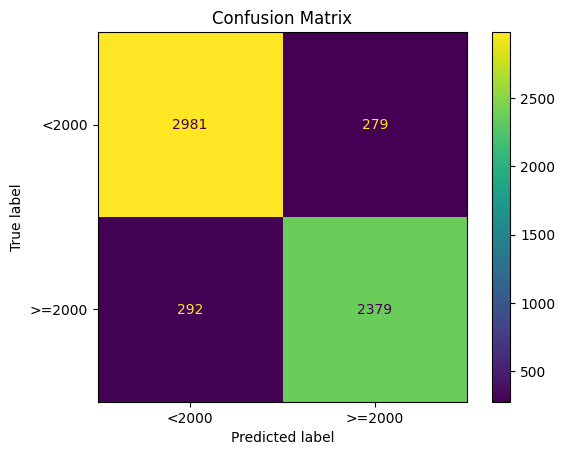

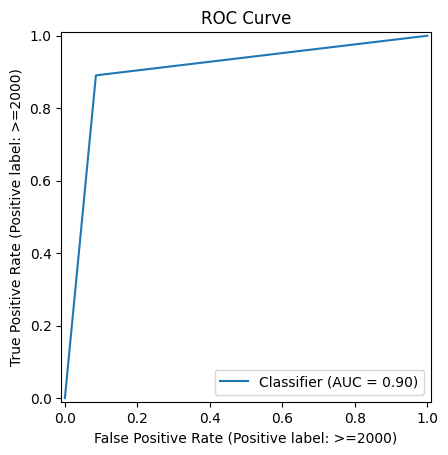

In [2]:
forest_clf = RandomForestClassifier(random_state=42)
start = time.time()
forest_clf.fit(X_train, y_train)
time_to_fit_forest_clf = time.time() - start
y_pred = cross_val_predict(forest_clf, X_train, y_train, cv=kfold_splitter) # 5-fold cross validation
forest_clf_accuracy_score = accuracy_score(y_train, y_pred)
print("Cross Validation Results of Random Forest Classifier")
print("----------------------------------------------------")
evaluate_classification_model(y_train, y_pred)

The Random Forest Classifier with default settings performs fairly well with an accuracy score of on average 90%. This is very good performance without any tuning or feature selection. Precision and Recall scores are roughly the same so the model performs equally well when predicting either class labels. Because of this, the rates of false positives and false negatives are roughly the same as well as shown in the confusion matrix.

#### Hyperparameter Tuning

In [3]:
params = RandomForestClassifier(random_state=42).get_params()
print(f"Current hyper parameters: \n {{'max_depth': {params['max_depth']}, 'min_samples_leaf': {params['min_samples_leaf']}, 'n_estimators': {params['n_estimators']}}}")
param_grid = {
    "n_estimators": [100, 250, 500],
    'min_samples_leaf': [1, 5, 15],
    'max_depth': [None, 10, 20, 30],
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=kfold_splitter, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best hyper parameters found with grid search: \n {grid_search.best_params_}\n")
tuned_forest_clf = grid_search.best_estimator_
print("Cross Validation Results of Tuned Random Forest Classifier")
print("----------------------------------------------------")
print(f"Accuracy score of Default Random Forest Classifier: {forest_clf_accuracy_score}")
print(f"Accuracy score of Tuned Random Forest Classifier: {grid_search.best_score_}")


Current hyper parameters: 
 {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
Best hyper parameters found with grid search: 
 {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 500}

Cross Validation Results of Tuned Random Forest Classifier
----------------------------------------------------
Accuracy score of Default Random Forest Classifier: 0.9037261844545608
Accuracy score of Tuned Random Forest Classifier: 0.9060863116590495


After tuning the hyperparameters of the random forest classifier. We found that the default settings yielded the best performance with one exception. The only setting that gives a marginal bump to accuracy score is increasing the number of trees generated ie. n_estimators

#### Feature Selection using RF

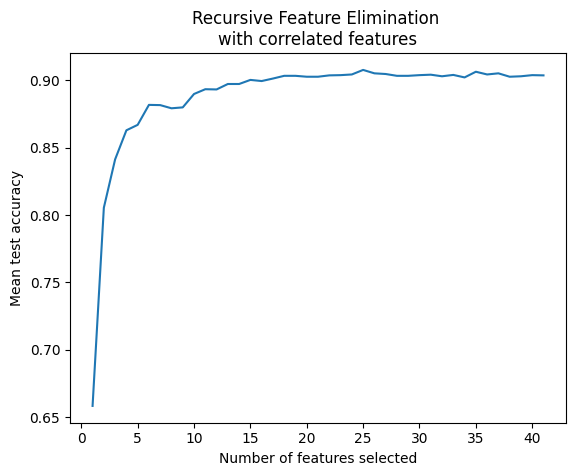

Total number of features: 41
Optimal number of features: 25
Selected Features: ['baths_standardized', 'beds_standardized', 'cats', 'dogs', 'furnishing_Furnished', 'furnishing_Unfurnished', 'healthCareCount_standardized', 'latitude_standardized', 'lease_term_Long Term', 'leisureCount_standardized', 'longitude_standardized', 'nearestPolice_standardized', 'nearestSchool_standardized', 'placeOfWorshipCount_standardized', 'restaurantCount_standardized', 'shopCount_standardized', 'sq_feet_standardized', 'tourismCount_standardized', 'type_Apartment', 'type_Basement', 'type_Condo Unit', 'type_House', 'type_Main Floor', 'type_Room For Rent', 'type_Townhouse']
Removed Features: ['type_Duplex', 'lease_term_Negotiable', 'furnishing_Negotiable', 'lease_term_Short Term', 'smoking_Non-Smoking', 'lease_term_12 months', 'smoking_Smoke Free Building', 'smoking_Negotiable', 'type_Loft', 'smoking_Smoking Allowed', 'type_Mobile', 'cemeteryCount_standardized', 'furnishing_Unfurnished, Negotiable', 'lease_te

In [4]:
rfe = RFECV(RandomForestClassifier(random_state=42), cv=kfold_splitter, scoring='accuracy', n_jobs=-1)
rfe.fit(X_train, y_train)
X_train_selected = rfe.transform(X_train)
rfe_forest_clf = RandomForestClassifier(random_state=42)
start = time.time()
rfe_forest_clf.fit(X_train_selected, y_train)
time_to_fit_rfe_forest_clf = time.time() - start
data = {
    key: value
    for key, value in rfe.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()
feature_names = X_train.columns.tolist()
ranked_features_with_names = sorted(zip(rfe.ranking_, feature_names))
selected_features = []
removed_features = []
for rank, feature in ranked_features_with_names:
    if rank == 1:
        selected_features.append(feature)
    else:
        removed_features.append(feature)
print(f"Total number of features: {len(INPUT_COLUMNS)}")
print(f"Optimal number of features: {rfe.n_features_}")
print(f"Selected Features: {selected_features}")
print(f"Removed Features: {removed_features}\n")
print("Cross Validation Results of RFE applied Random Forest Classifier")
print("----------------------------------------------------")
print(f"Accuracy score of Default Random Forest Classifier: {forest_clf_accuracy_score}")
print(f"Accuracy score of RFE applied Random Forest Classifier: {rfe.cv_results_['mean_test_score'].max()}")
print(f"Time to train Default Random Forest Classifier: {time_to_fit_forest_clf}")
print(f"Time to train RFE applied Random Forest Classifier: {time_to_fit_rfe_forest_clf}")

After applying RFE, we got a marginal increase to our accuracy score. Even though roughly 40 percent of the features were removed, we were still able to achieve a good accuracy score. We did not see any increase in computational efficiency when fitting with the 25 features over the entire 41 features.

#### Model Performance on unseen data

In [5]:
print(f"Random Forest Classifier accuracy score: {accuracy_score(y_test, forest_clf.predict(X_test))}")
print(f"Tuned Random Forest Classifier accuracy score: {accuracy_score(y_test, tuned_forest_clf.predict(X_test))}")
print(f"RFE applied Random Forest Classifier accuracy score: {accuracy_score(y_test, rfe.estimator_.predict(rfe.transform(X_test)))}")

Random Forest Classifier accuracy score: 0.8984848484848484
Tuned Random Forest Classifier accuracy score: 0.896969696969697
RFE applied Random Forest Classifier accuracy score: 0.9015151515151515


Testing the models with our test data, we can see that the RFE applied random forest classifier performs the best, albeit only by a little bit.

## Logistic Regression

Cross Validation Results of Logistic Regression Classifier
----------------------------------------------------
accuracy: 0.8846737481031867
">=2000" is the positive class, and "<2000" is the negative class
precision: 0.8807972403219624
recall: 0.8603519281168102
f1_score: 0.8704545454545455
auc_roc: 0.8824765775553376


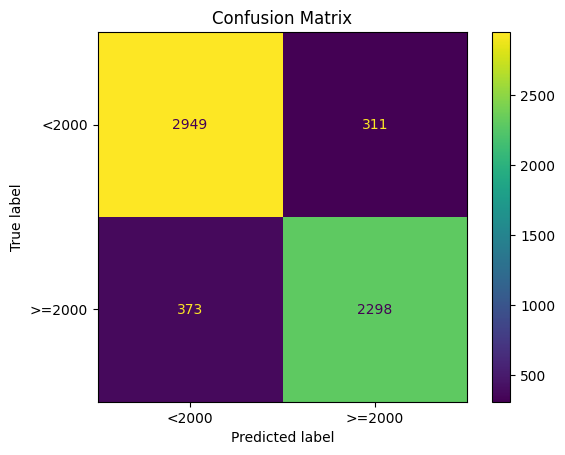

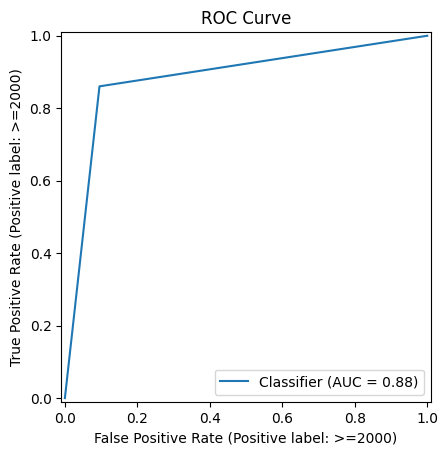

In [6]:
lr_clf = LogisticRegression(random_state=42)
lr_clf.fit(X_train, y_train)
y_pred = cross_val_predict(lr_clf, X_train, y_train, cv=kfold_splitter) # 5-fold cross validation
print("Cross Validation Results of Logistic Regression Classifier")
print("----------------------------------------------------")
lr_clf_accuracy_score = accuracy_score(y_train, y_pred)
evaluate_classification_model(y_train, y_pred)

The logistic regression classifier model performs fairly well with an accuracy score of roughly 88%, but not as well as our random forest classifier. With its precision and recall score roughly the same, the model performs equally well on predicting both class labels, we can also see this in the roughly equal number of false negative and false positives predicted.

#### Hyperparameter Tuning

In [7]:
params = LogisticRegression(random_state=42).get_params()
print(f"Current hyper parameters: \n {{'C': {params['C']}, 'max_iter': {params['max_iter']},'solver': {params['solver']}}}")
param_grid = {
    'C': [ 0.001, 0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 500, 1000],
    'solver': ['lbfgs', 'liblinear', 'newton-cholesky', 'newton-cg'],
}
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=kfold_splitter, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(f"Best hyper parameters found with grid search: \n {grid_search.best_params_}\n")
y_pred = cross_val_predict(grid_search.best_estimator_, X_train, y_train, cv=kfold_splitter) # 5-fold cross validation
print("Cross Validation Results of Tuned Logistic Regression Classifier")
print("----------------------------------------------------")
print(f"Accuracy score of Default Logistic Regression Classifier: {lr_clf_accuracy_score}")
print(f"Accuracy score of Tuned Logistic Regression Classifier: {grid_search.best_score_}")

Current hyper parameters: 
 {'C': 1.0, 'max_iter': 100,'solver': lbfgs}
Best hyper parameters found with grid search: 
 {'C': 1, 'max_iter': 100, 'solver': 'newton-cholesky'}

Cross Validation Results of Tuned Logistic Regression Classifier
----------------------------------------------------
Accuracy score of Default Logistic Regression Classifier: 0.8846737481031867
Accuracy score of Tuned Logistic Regression Classifier: 0.8851803759388883


After tuning the hyperparameters, we can see that most of the default settings are already optimal except for the "solver" parameter. The newton-cholesky gives a very marginal accuracy score boost over the default settings.

#### Model Performance on unseen data

In [8]:
print(f"Logistic Regression accuracy score: {accuracy_score(y_test, lr_clf.predict(X_test))}")
print(f"Tuned Logistic Regression accuracy score: {accuracy_score(y_test, grid_search.best_estimator_.predict(X_test))}")

Logistic Regression accuracy score: 0.8742424242424243
Tuned Logistic Regression accuracy score: 0.8727272727272727


Testing the models with our test data, we can see that our default logistic regression classifier performs better, albeit only by a very little bit.